## Лабораторная работа №5
### Компьютерное зрение

**Выполнил:** Изгородин Илья Юрьевич  
**Группа:** ФИТ-232  
**Факультет:** ФИТиКС ОмГТУ  

*Омск, 2026*

Перед началом выполнения работы устанавливаю и импотрирую библиотеки, необходимые для поставленных заданий

In [58]:
!pip install opencv-python matplotlib numpy scikit-learn scikit-image torch torchvision

In [59]:
import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
from skimage.feature import hog as sk_hog
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from torchvision.datasets import CIFAR10
from torchvision import transforms
import warnings, time

warnings.filterwarnings('ignore')
torch.manual_seed(42)
np.random.seed(42)

In [60]:
device = torch.device('cuda')

Загружаю датасеты

In [61]:
def load_cifar10():
    tf = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5,)*3, (0.5,)*3)])
    tr = CIFAR10('./data', train=True, download=True, transform=tf)
    te = CIFAR10('./data', train=False, download=True, transform=tf)
    
    def unpack(ds):
        X, y = [], []
        for img, lbl in ds:
            X.append(np.array(img).transpose(1,2,0) * 127.5 + 127.5)
            y.append(lbl)
        return np.array(X).astype(np.float32), np.array(y)
    return *unpack(tr), *unpack(te)

X_train, y_train, X_test, y_test = load_cifar10()

Оглашаю функции извлечения признаков из изображений, извлекаю признаки

In [62]:
def feat_hist(img):
    return np.hstack([np.histogram(img[:,:,c].ravel(), 64, (0,255))[0]/64 for c in range(3)]).astype(np.float32)

def feat_hog(img):
    gray = cv2.cvtColor(img.astype(np.uint8), cv2.COLOR_RGB2GRAY)
    return sk_hog(gray, orientations=9, pixels_per_cell=(8,8), cells_per_block=(2,2), 
                  transform_sqrt=True, visualize=False, feature_vector=True).astype(np.float32)

def extract_feats(images, method):
    fn = feat_hist if method=='histogram' else feat_hog
    return np.vstack([fn(img) for img in images])

In [63]:
X_tr_h = extract_feats(X_train, 'histogram')
X_te_h = extract_feats(X_test, 'histogram')
X_tr_g = extract_feats(X_train, 'hog')
X_te_g = extract_feats(X_test, 'hog')

Масштабирую признаки

In [64]:
sc_h, sc_g = StandardScaler(), StandardScaler()
X_tr_h = sc_h.fit_transform(X_tr_h); X_te_h = sc_h.transform(X_te_h)
X_tr_g = sc_g.fit_transform(X_tr_g); X_te_g = sc_g.transform(X_te_g)

Оглашаю модели, обучаю, оцениваю метриками

In [65]:
models = {
    'LR': LogisticRegression(max_iter=1000, multi_class='multinomial', n_jobs=-1),
    'RF': RandomForestClassifier(n_estimators=50, max_depth=8, random_state=42, n_jobs=-1),
    'KNN': KNeighborsClassifier(n_neighbors=5, n_jobs=-1)
}
results = {}

for name, model in models.items():
    t0 = time.time()
    model.fit(X_tr_h, y_train)
    acc = accuracy_score(y_test, model.predict(X_te_h))
    results[f"{name}_H"] = {'acc': acc, 'model': model, 'time': time.time()-t0}

Смотрю несколько тестовых предсказаний

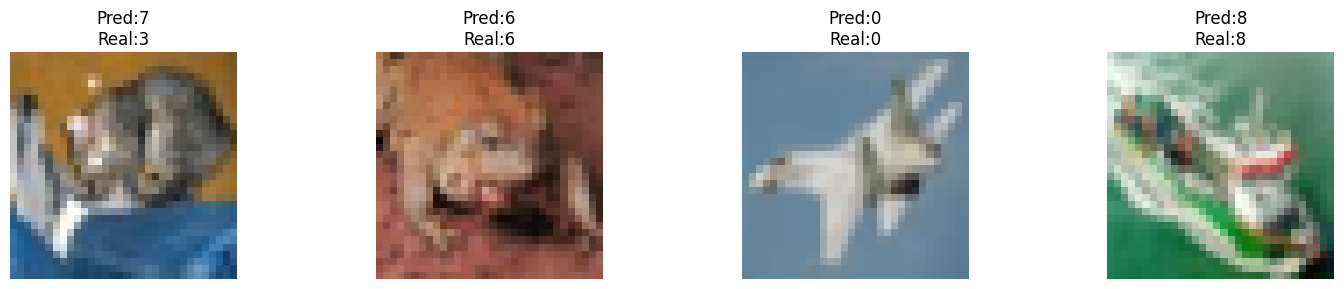

In [67]:
fig, ax = plt.subplots(1, 4, figsize=(15,3))
for i, idx in enumerate([0,5,10,15]):
    ax[i].imshow(X_test[idx].astype(np.uint8))
    pred = results['RF_H']['model'].predict([X_te_h[idx]])[0]
    ax[i].set_title(f"Pred:{pred}\nReal:{y_test[idx]}"); ax[i].axis('off')
plt.tight_layout(); plt.show()

Готовлю данные для обучения нейросетей

In [68]:
def prep_fcnn(Xtr, Xte, ytr, yte):
    sc = StandardScaler()
    tr = TensorDataset(torch.FloatTensor(sc.fit_transform(Xtr.reshape(len(Xtr),-1))), torch.LongTensor(ytr))
    te = TensorDataset(torch.FloatTensor(sc.transform(Xte.reshape(len(Xte),-1))), torch.LongTensor(yte))
    return DataLoader(tr, 64, True), DataLoader(te, 64)

train_ld, test_ld = prep_fcnn(X_train, X_test, y_train, y_test)

Оглашаю FCNN

In [69]:
class FCNN(nn.Module):
    def __init__(self, inp=3072, h=[512,256], cls=10):
        super().__init__()
        dims = [inp] + h + [cls]
        layers = []
        for i in range(len(dims)-1):
            layers.append(nn.Linear(dims[i], dims[i+1]))
            if i < len(dims)-2: layers += [nn.ReLU(), nn.Dropout(0.3)]
        self.net = nn.Sequential(*layers)
    def forward(self, x): return self.net(x)

model_fcn = FCNN().to(device)
opt_fcn = optim.Adam(model_fcn.parameters(), lr=1e-3)
crit_fcn = nn.CrossEntropyLoss()

Запускаю обучение FCNN

In [70]:
def train_fcn(mdl, ld, ep=15):
    L, A = [], []
    for _ in range(ep):
        mdl.train(); tl, cor = 0, 0
        for X, y in ld:
            X, y = X.to(device), y.to(device)
            opt_fcn.zero_grad()
            loss = crit_fcn(mdl(X), y); loss.backward(); opt_fcn.step()
            tl += loss.item(); cor += (mdl(X).argmax(1)==y).sum().item()
        L.append(tl/len(ld)); A.append(cor/len(ld.dataset))
    return L, A

losses_fcn, accs_fcn = train_fcn(model_fcn, train_ld, 15)

Оцениваю изменение функции потерь и метрику точности

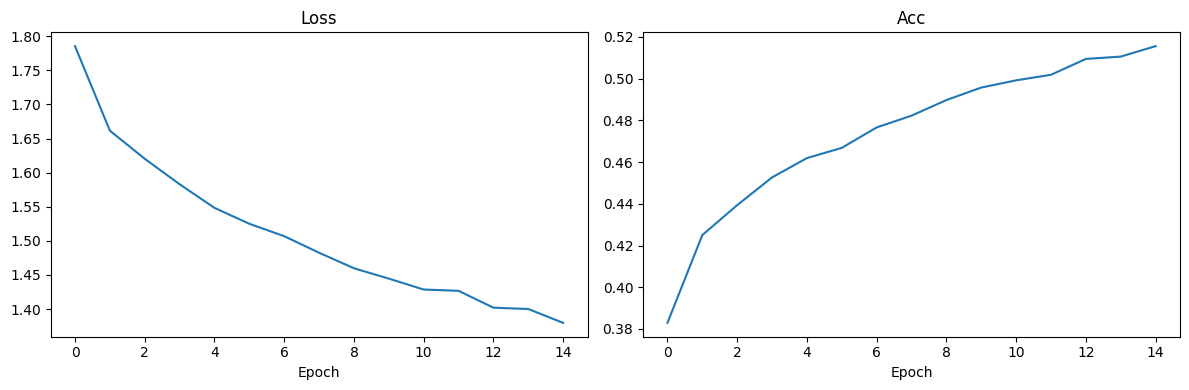

In [71]:
fig, ax = plt.subplots(1, 2, figsize=(12,4))
ax[0].plot(losses_fcn); ax[0].set_title('Loss'); ax[0].set_xlabel('Epoch')
ax[1].plot(accs_fcn); ax[1].set_title('Acc'); ax[1].set_xlabel('Epoch')
plt.tight_layout(); plt.show()

Смотрю несколько тестовых предсказаний

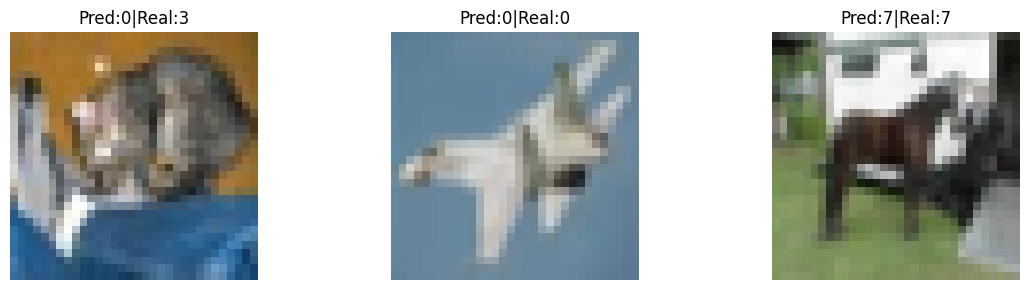

In [73]:
fig, ax = plt.subplots(1, 3, figsize=(12,3))
with torch.no_grad():
    for i, idx in enumerate([0,10,20]):
        ax[i].imshow(X_test[idx].astype(np.uint8))
        p = model_fcn(torch.FloatTensor(X_test[idx].reshape(1,-1)).to(device)).argmax(1).item()
        ax[i].set_title(f"Pred:{p}|Real:{y_test[idx]}"); ax[i].axis('off')
plt.tight_layout(); plt.show()

Оглашаю CNN

In [74]:
class CNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(3,32,3,padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32,64,3,padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Flatten(), nn.Linear(64*8*8,128), nn.ReLU(), nn.Dropout(0.3), nn.Linear(128,10))
    def forward(self, x): return self.net(x)

model_cnn = CNN().to(device)
opt_cnn = optim.Adam(model_cnn.parameters(), lr=1e-3)
crit_cnn = nn.CrossEntropyLoss()

Готовлю данные для обучения CNN

In [75]:
def prep_cnn(Xtr, Xte, ytr, yte):
    tr = TensorDataset(torch.FloatTensor(Xtr).permute(0,3,1,2).to(device), torch.LongTensor(ytr).to(device))
    te = TensorDataset(torch.FloatTensor(Xte).permute(0,3,1,2).to(device), torch.LongTensor(yte).to(device))
    return DataLoader(tr, 64, True), DataLoader(te, 64)

loader_cnn, test_loader_cnn = prep_cnn(X_train, X_test, y_train, y_test)

Запускаю обучение CNN

In [76]:
def train_cnn(mdl, ld, tld, ep=15):
    L, TA, VA = [], [], []
    for _ in range(ep):
        mdl.train(); tl, cor = 0, 0
        for X, y in ld:
            opt_cnn.zero_grad(); loss = crit_cnn(mdl(X), y); loss.backward(); opt_cnn.step()
            tl += loss.item(); cor += (mdl(X).argmax(1)==y).sum().item()
        L.append(tl/len(ld)); TA.append(cor/len(ld.dataset))
        mdl.eval(); c, t = 0, 0
        with torch.no_grad():
            for X, y in tld: c += (mdl(X).argmax(1)==y).sum().item(); t += y.size(0)
        VA.append(c/t)
    return L, TA, VA

losses_cnn, tr_acc_cnn, val_acc_cnn = train_cnn(model_cnn, loader_cnn, test_loader_cnn, 15)

Оцениваю график изменения функции потерь и метрику точности

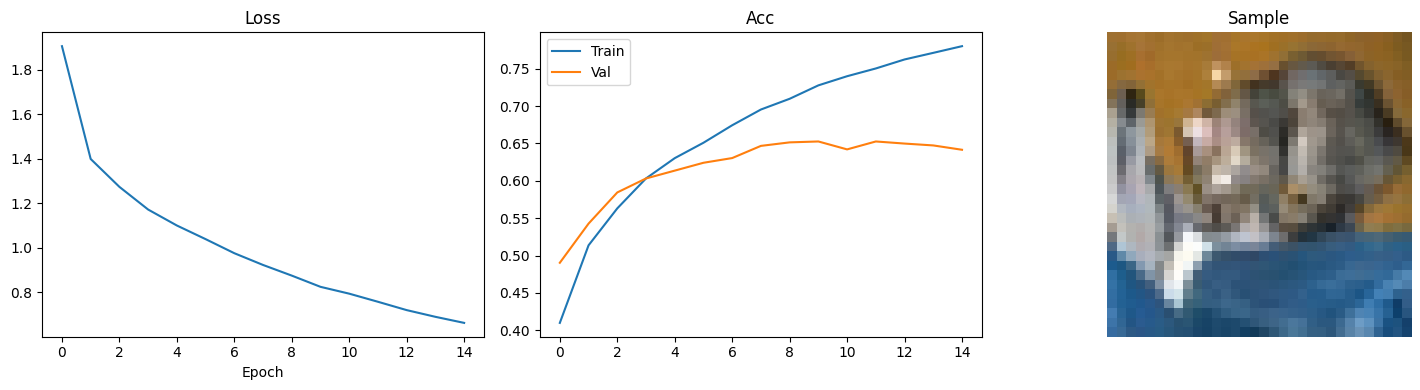

In [77]:
fig, ax = plt.subplots(1, 3, figsize=(15,4))
ax[0].plot(losses_cnn); ax[0].set_title('Loss'); ax[0].set_xlabel('Epoch')
ax[1].plot(tr_acc_cnn, label='Train'); ax[1].plot(val_acc_cnn, label='Val'); ax[1].legend(); ax[1].set_title('Acc')
ax[2].imshow(X_test[0].astype(np.uint8)); ax[2].set_title('Sample'); ax[2].axis('off')
plt.tight_layout(); plt.show()

Смотрю несколько тестовых предсказаний

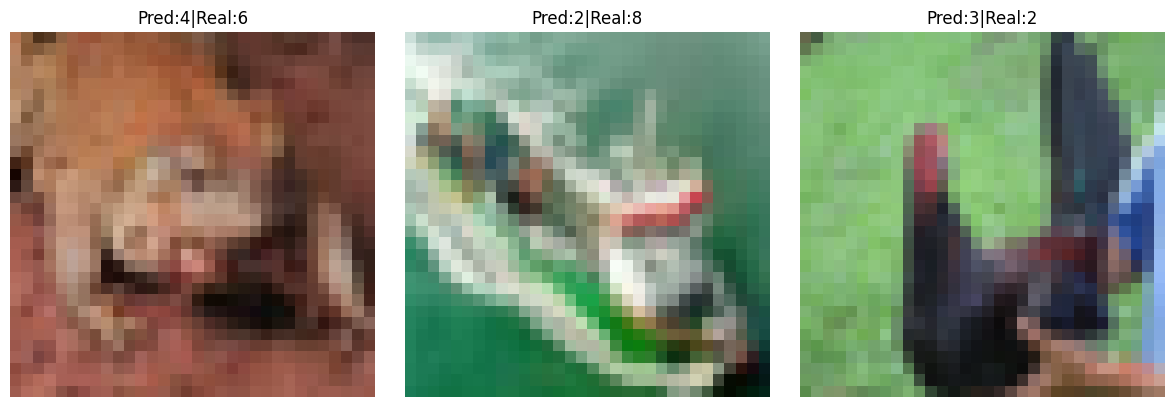

In [79]:
fig, ax = plt.subplots(1, 3, figsize=(12,4))
with torch.no_grad():
    for i, idx in enumerate([5,15,25]):
        ax[i].imshow(X_test[idx].astype(np.uint8))
        p = model_cnn(torch.FloatTensor(X_test[idx].reshape(1,3,32,32)).to(device)).argmax(1).item()
        ax[i].set_title(f"Pred:{p}|Real:{y_test[idx]}"); ax[i].axis('off')
plt.tight_layout(); plt.show()

Оцениваю метриками полученные модели

In [80]:
def evaluate_all():
    info = []
    for k in ['LR_H','RF_H','KNN_H']:
        r = results[k]; y_pred = r['model'].predict(X_te_h)
        rep = classification_report(y_test, y_pred, output_dict=True)
        info.append({'Model':f"{k.split('_')[0]}(Hist)",'Type':'Classical','Acc':round(r['acc'],4),
                     'P':round(rep['weighted avg']['precision'],4),'R':round(rep['weighted avg']['recall'],4),
                     'F1':round(rep['weighted avg']['f1-score'],4),'Time':round(r['time'],2)})
    
    model_fcn.eval(); c,t=0,0
    with torch.no_grad():
        for X,y in test_ld: X,y=X.to(device),y.to(device); c+=(model_fcn(X).argmax(1)==y).sum().item();t+=y.size(0)
    info.append({'Model':'FCNN(Pixels)','Type':'NN','Acc':round(c/t,4),'P/R/F1':'-','Time':'-'})
    
    model_cnn.eval(); c,t=0,0
    with torch.no_grad():
        for X,y in test_loader_cnn: X,y=X.to(device),y.to(device); c+=(model_cnn(X).argmax(1)==y).sum().item();t+=y.size(0)
    info.append({'Model':'CNN(32x32x3)','Type':'CNN','Acc':round(c/t,4),'P/R/F1':'-','Time':'-'})
    
    return pd.DataFrame(info).sort_values('Acc',ascending=False).reset_index(drop=True)

evaluate_all()

,Model,Type,Acc,P,R,F1,Time,P/R/F1
0,CNN(32x32x3),CNN,0.6416,NaN,NaN,NaN,-,-
1,FCNN(Pixels),NN,0.5085,NaN,NaN,NaN,-,-
2,RF(Hist),Classical,0.3163,0.3110,0.3163,0.2935,0.49,NaN
3,KNN(Hist),Classical,0.2846,0.2900,0.2846,0.2796,0.71,NaN
4,LR(Hist),Classical,0.2689,0.2602,0.2689,0.2590,5.13,NaN
